# Laboratorium 5 - Logic Gate Net.

In [1]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.datasets import make_moons
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import numpy as np

### Generowanie danych:

In [2]:
X, y = make_moons(n_samples=500, noise=0.15, random_state=42)
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

### Funkcja z definicjami bramek logicznych:

In [3]:
def get_gates_results(a, b):
    op_and = a * b
    op_or = a + b - op_and
    op_xor = a + b - 2 * op_and

    ops = [
        torch.zeros_like(a), # 0: False
        op_and, # 1: A AND B
        a * (1 - b), # 2: A AND NOT B
        a, # 3: A
        b * (1 - a), # 4: B AND NOT A
        b, # 5: B
        op_xor, # 6: XOR
        op_or, # 7: OR
        1 - op_or, # 8: NOR
        1 - op_xor, # 9: XNOR
        1 - b, # 10: NOT B
        1 - (b * (1 - a)), # 11: A OR NOT B
        1 - a, # 12: NOT A
        1 - (a * (1 - b)), # 13: B OR NOT A
        1 - op_and, # 14: NAND
        torch.ones_like(a) # 15: True
    ]
    return torch.stack(ops, dim=-1)

### Pojedyncza warstwa:

Każda warstwa zawiera X neuronów.

Neuron posiada wagi dla każdej bramki logicznej, oraz wybrane dwa wejścia z poprzedniej warstwy.

Hard mode - przy testowaniu - wybiera zawsze najlepszą bramkę. 

Soft mode - przy trenowaniu - aktualizuje wagi dla każdej bramki przy użyciu funkcji softmax i przekazuje dalej średnią ważoną wartości ze wszystkich bramek.

In [4]:
class GatesLayer(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.indices = torch.randint(0, input_dim, (2, output_dim))
        self.gate_weights = nn.Parameter(torch.randn(output_dim, 16))

    def forward(self, x, hard_mode=False):
        a = x[:, self.indices[0]]
        b = x[:, self.indices[1]]
        gates = get_gates_results(a, b)
        
        if hard_mode:
            best_gate = self.gate_weights.argmax(dim=-1)
            idx = best_gate.view(1, -1, 1).expand(x.size(0), -1, -1)
            return gates.gather(2, idx).squeeze(-1)
        else:
            probs = F.softmax(self.gate_weights, dim=-1)
            return (gates * probs.unsqueeze(0)).sum(dim=-1)

### Klasa sieci bramkowej:

Przelicza całą sieć i na końcu używa funkcji Sigmoid do klasyfikacji (zwraca wynik w zakresie 0-1). 

In [5]:
class GatesNetwork(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=64, num_layers=3):
        super().__init__()
        self.layers = nn.ModuleList()
        
        curr_dim = input_dim
        for _ in range(num_layers):
            self.layers.append(GatesLayer(curr_dim, hidden_dim))
            curr_dim = hidden_dim
        
        self.output_bias = nn.Parameter(torch.tensor(0.0))

    def forward(self, x, hard_mode=False):
        for layer in self.layers:
            x = layer(x, hard_mode)
        
        score = x.mean(dim=1, keepdim=True) + self.output_bias
        return torch.sigmoid(score)

### Ewaluacja modelu:

In [6]:
model = GatesNetwork(input_dim=2, hidden_dim=128, num_layers=4)
optimizer = optim.Adam(model.parameters(), lr=0.02)
criterion = nn.BCELoss()

In [7]:
print(f"{'Epoka':<10} | {'Loss':<10} | {'Soft Acc':<10} | {'Hard Acc':<10}")
print("-" * 50)
for epoch in range(501):
    model.train()
    optimizer.zero_grad()
    
    preds = model(X_tensor, hard_mode=False)
    loss = criterion(preds, y_tensor)
    
    loss.backward()
    optimizer.step()
    
    if epoch % 50 == 0:
        soft_acc = ((preds > 0.5) == y_tensor).float().mean()
        
        with torch.no_grad():
            hard_preds = model(X_tensor, hard_mode=True)
            hard_acc = ((hard_preds > 0.5) == y_tensor).float().mean()
            
        print(f"{epoch:<10} | {loss.item():<10.4f} | {soft_acc.item():<10.2f} | {hard_acc.item():<10.2f}")

Epoka      | Loss       | Soft Acc   | Hard Acc  
--------------------------------------------------
0          | 0.7235     | 0.50       | 0.50      
50         | 0.6884     | 0.50       | 0.50      
100        | 0.6368     | 0.86       | 0.86      
150        | 0.6015     | 0.86       | 0.87      
200        | 0.5911     | 0.86       | 0.86      
250        | 0.5869     | 0.86       | 0.86      
300        | 0.5848     | 0.86       | 0.86      
350        | 0.5835     | 0.86       | 0.86      
400        | 0.5827     | 0.86       | 0.86      
450        | 0.5823     | 0.87       | 0.86      
500        | 0.5821     | 0.86       | 0.86      


### Wizualizacja wyników: 


Generowanie macierzy pomyłek...


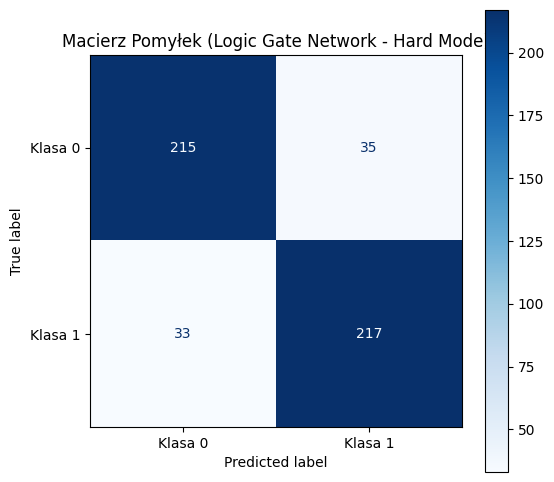

In [ ]:
def show_confusion_matrix(model, X_tensor, y_true):
    model.eval()
    with torch.no_grad():
        preds_prob = model(X_tensor, hard_mode=True)
        preds_class = (preds_prob > 0.5).float().numpy()
        
    y_true_np = y_true.numpy()
    
    cm = confusion_matrix(y_true_np, preds_class)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Klasa 0", "Klasa 1"])
    
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
    plt.title("Macierz Pomyłek (Logic Gate Network - Hard Mode)")
    plt.show()

show_confusion_matrix(model, X_tensor, y_tensor)